In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import json

import constants
from model_utils import *
from performance_utils import *

from ast import literal_eval
from pathlib import Path
 
import matplotlib.cm as cm
import ast
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
from pprint import pprint

In [2]:
plt.style.use('ggplot')
sns.set_palette('hls', 18)
SPLIT = 'validation'
model_type = constants.RectalCancerStagingData
base_dir = Path.cwd().parent

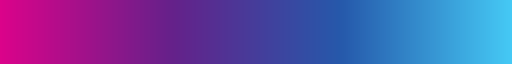

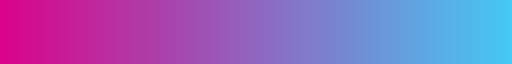

In [3]:
finomnia_palette = sns.color_palette(('#db038a',   # Pink
                                      '#66218a',   # Violet
                                      '#081c36',   # Dark Blue
                                      '#2659ab',   # blue
                                      '#45c9f5'))  # Light blue
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[1], finomnia_palette[-2], finomnia_palette[-1]])
display(finomnia_cmap)
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[-1]])
display(finomnia_cmap)


In [4]:
# Get ORIGINAL DATA
data_path = base_dir / 'data' / constants.RAW_DATA_FILE_NAME
data = pd.read_csv(data_path)
#data = data[['id', 'report_text']]
data.sort_values(by='id', inplace=True, ignore_index=True)


# delete column "posizione" as it is obsolete, renaming "posizione_multiple" in "posizione"
data.drop(columns=['posizione'], inplace=True)
data.rename(columns={'posizione_multiple': 'posizione'}, inplace=True)

sedi_linfonodi = []
for s1, s2 in zip(data.sedi_locoregionali, data.sedi_non_locoregionali):
    sedi_linfonodi.append(str(ast.literal_eval(s1) + ast.literal_eval(s2)))
data['sedi_linfonodi'] = sedi_linfonodi
print(f'Nuova colonna "sedi_linfonodi" creata\n{data.shape = }')

#####################
# Columns aggregation
#####################
# Dettagli infiltrazione organi
infiltrazione_organi_dettagli_new = []
for s in data.infiltrazione_organi_dettagli.fillna(constants.NAN_VALUE):
    dettagli = []
    if s == constants.NAN_VALUE:
        infiltrazione_organi_dettagli_new.append(str(dettagli))
    else:
        if s.strip() == '[object Object]':
            infiltrazione_organi_dettagli_new.append(str(dettagli))
            continue 
        d = ast.literal_eval(s)
        if constants.InfiltrazioneOrganiDettagli.PAVIMENTO_PELVICO.value in d:
            dettagli.append(constants.InfiltrazioneOrganiDettagli.PAVIMENTO_PELVICO.value)
        if ('altro' in d) or ('utero' in d) or ('sacro' in d):
            dettagli.append(constants.InfiltrazioneOrganiDettagli.ALTRO.value)
        infiltrazione_organi_dettagli_new.append(str(dettagli))
data.loc[:, 'infiltrazione_organi_dettagli'] = infiltrazione_organi_dettagli_new


data.set_index('id', inplace=True)
print(f'{data.shape = }')

Nuova colonna "sedi_linfonodi" creata
data.shape = (343, 45)
data.shape = (343, 44)


In [5]:
greens =    sns.color_palette('Greens', 10)
blues =     sns.color_palette('Blues', 10)
oranges =   sns.color_palette('Oranges', 10)
reds =      sns.color_palette('Reds', 10)
purples =   sns.color_palette('Purples', 10)
greys =     sns.color_palette('Greys', 10)

In [6]:

mistral_train = load_results_data("results_TRAIN_mistral_large_3.jsonl", base_dir/'data'/'inference', model_type)
mistral = load_results_data("results_mistral_large_3.jsonl", base_dir/'data'/'inference', model_type)
gpt_train = load_results_data("results_TRAIN_gpt-4.1.jsonl", base_dir/'data'/'inference', model_type)
gpt = load_results_data("results_gpt-4.1.jsonl", base_dir/'data'/'inference', model_type)
opus_train = load_results_data("results_TRAIN_opus-4.6.jsonl", base_dir/'data'/'inference', model_type)
opus = load_results_data("results_opus-4.6.jsonl", base_dir/'data'/'inference', model_type)

assert len(mistral_train) == len(gpt_train) == len(opus_train)
assert len(mistral) == len(gpt) == len(opus)

mistral = mistral_train + mistral
gpt = gpt_train + gpt
opus = opus_train + opus

mistral = {
    ex['id']: {
        'actual':       ex['actual'],
        'prediction':   ex['prediction'],
        'split':        ex['split']
    }
    for ex in mistral
}
gpt = {
    ex['id']: {
        'actual':       ex['actual'],
        'prediction':   ex['prediction'],
        'split':        ex['split']
    }
    for ex in gpt
}
opus = {
    ex['id']: {
        'actual':       ex['actual'],
        'prediction':   ex['prediction'],
        'split':        ex['split']
    }
    for ex in opus
}

# Controllo
for id in mistral:
    if mistral[id]['actual'] == gpt[id]['actual'] == opus[id]['actual']:
        continue
    else:
        print(id)

results = {
    id: {
        'actual':   gpt[id]['actual'],
        'gpt':      gpt[id]['prediction'],
        'opus':     opus[id]['prediction'],
        'mistral':  mistral[id]['prediction'],
    }
    for id in gpt
}

reports = {id: data.loc[id]['report_text'] for id in gpt}
profiles = {id: data.loc[id]['profile'] for id in gpt}

In [7]:
def report_model_to_dataframe(report_model: constants.RectalCancerStagingData, name: str) -> pd.DataFrame:
    multilabel_fields = ['posizione', 'infiltrazione_organi_dettagli', 'sedi_linfonodi']    
    model_dict = report_model.model_dump(mode='json')
    
    for f in multilabel_fields:
        label_list = []
        for l, v in model_dict[f].items():
            if v == constants.Flag.SI.value:
                label_list.append(l)
        model_dict[f] = label_list
    s = pd.Series(model_dict)
    s.name = name
    return s.to_frame()

In [8]:
def original_to_df(id: int, original_data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    result = original_data.loc[id, columns].T
    result.name = 'original'
    return result.to_frame()

In [9]:
def highlight_diff(row, color: str = 'red'):
    ref = row.iloc[1]  # prima colonna come riferimento
    styles = ['', '']  # nessuno stile per la colonna di riferimento
    for val in row.iloc[2:]:  # ultime tre colonne
        if val != ref:
            styles.append(f'background-color: {color}')
        else:
            styles.append('')
    return styles

In [10]:
print(reports.keys())

dict_keys([46, 47, 51, 54, 57, 59, 66, 74, 87, 88, 92, 98, 106, 108, 111, 116, 120, 126, 129, 130, 131, 132, 140, 153, 160, 163, 165, 174, 178, 181, 184, 185, 186, 188, 190, 191, 193, 194, 195, 196, 199, 204, 207, 208, 209, 210, 214, 221, 224, 225, 227, 229, 230, 231, 232, 234, 237, 241, 242, 243, 244, 246, 248, 250, 251, 257, 258, 260, 262, 263, 270, 271, 273, 275, 276, 282, 284, 288, 290, 291, 292, 294, 295, 296, 297, 298, 300, 302, 303, 305, 306, 307, 310, 311, 312, 313, 314, 315, 316, 318, 320, 322, 323, 324, 325, 326, 329, 331, 333, 334, 335, 336, 337, 338, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 373, 374, 375, 376, 377, 379, 380, 381, 384, 386, 387, 388, 389, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 407, 409, 410, 411, 412, 413, 415, 416, 418, 419, 420, 421, 422, 53, 56, 67, 69, 75, 78, 79, 82, 97, 99, 100, 104, 109, 112, 115, 119, 125, 135, 1

In [452]:
id = 219
original = original_to_df(id, data, list(constants.RectalCancerStagingData.model_fields.keys()))
dfs = [original] + [report_model_to_dataframe(r, n) for n, r in results[id].items()]
df = pd.concat(dfs, axis=1)
print(data.loc[id].interpretazioni)
styled = df.style.apply(highlight_diff, color='red', axis=1)

- INCONGRUENZA: RETTO MEDIO-BASSO in referto, RETTO MEDIO-ALTO in conclusione
- T4 in conclusione: non è chiaro se intende T4a perchè considera coinvolgimento del peritoneo in alto, oppure se si tratta sempre di MRF, considerato che non abbiamo altre info sul T, mettiamo classe più bassa T4a
-non avevi inserito "Distanza più breve fra tumore e fascia mesorettale: ore 8"
-avevi inserito 4 a "Numero linfonodi regionali sospetti", ma il numero non è specificato, abbiamo solo N2 ma non un numero preciso perciò non sappiamo se N2a o N2b, mettiamo classe piu bassa N2a


In [453]:
print(id, profiles[id])
pprint(reports[id])

219 PietroPaoloAzzaro
('RM ADDOME INFERIORE\n'
 ' \n'
 "L'ESAME E STATO ESEGUITO MEDIANTE SEQUENZE FSE,DWI.\n"
 ' \n'
 'SI SEGNALA ISPESSIMENTO PARIETALE CONCENTRICO DEL RETTO MEDIO-ALTO CHE SI '
 'ESTENDE DA CIRCA 5 CM DALLO SFINTERE ANALE INTERNO CRANIALMENTE PER CIRCA '
 '8,5 CM.\n'
 "L' ISPESSIMENTO PARIETALE, MODERATAMENTE IPERINTENSO ALLE SEQUENZE "
 'T2-DIPENDENTI , RETRAE IN UN PUNTO IL PERITONEO E CON UNA DIGITAZIONE '
 'RAGGIUNGE IL COLLO UTERINO.\n'
 'UTERO IN ATROFIA POST-MENOPAUSALE.\n'
 'NEL CANALE CERVICALE E PRESENTE UNA FALDA FLUIDA.\n'
 'NEL MESORETTO E LUNGO I VASI EMORROIDARI SUPERIORI SONO PRESENTI LINFONODI '
 'SOPSETTI IN NUMERO SUPERIORE A TRE , I MAGGIORI CON ASSE CORTO DI CIRCA 7 '
 'MM.\n'
 'LINFONODI DI NATURA ASPECIFICA IN SEDE INGUINALE BILATERALE.\n'
 ' \n'
 'STADIAZIONE RM T4BN2')


In [454]:
print(id)
display(styled)
print(id, profiles[id])
pprint(reports[id])

219


,original,actual,gpt,opus,mistral
morfologia,solido_anulare,solido_anulare,solido_anulare,solido_anulare,solido_anulare
ore_inizio,nan,None,None,None,None
ore_fine,nan,None,None,None,None
spessore_parietale,nan,None,None,None,None
estensione_cranio_caudale,85.000000,85,85,85,85
distanza_oai,50.000000,50,50,50,50
posizione,['alto'],['alto'],"['medio', 'alto']","['medio', 'alto']","['medio', 'alto']"
riflessione_peritoneale_anteriore,cavallo,cavallo,cavallo,cavallo,cavallo
infiltrazione_tessuto_adiposo,si_5mm_plus,si_5mm_plus,si_5mm_plus,si_5mm_plus,si_5mm_plus
infiltrazione_sfinteri,no,no,no,no,no


219 PietroPaoloAzzaro
('RM ADDOME INFERIORE\n'
 ' \n'
 "L'ESAME E STATO ESEGUITO MEDIANTE SEQUENZE FSE,DWI.\n"
 ' \n'
 'SI SEGNALA ISPESSIMENTO PARIETALE CONCENTRICO DEL RETTO MEDIO-ALTO CHE SI '
 'ESTENDE DA CIRCA 5 CM DALLO SFINTERE ANALE INTERNO CRANIALMENTE PER CIRCA '
 '8,5 CM.\n'
 "L' ISPESSIMENTO PARIETALE, MODERATAMENTE IPERINTENSO ALLE SEQUENZE "
 'T2-DIPENDENTI , RETRAE IN UN PUNTO IL PERITONEO E CON UNA DIGITAZIONE '
 'RAGGIUNGE IL COLLO UTERINO.\n'
 'UTERO IN ATROFIA POST-MENOPAUSALE.\n'
 'NEL CANALE CERVICALE E PRESENTE UNA FALDA FLUIDA.\n'
 'NEL MESORETTO E LUNGO I VASI EMORROIDARI SUPERIORI SONO PRESENTI LINFONODI '
 'SOPSETTI IN NUMERO SUPERIORE A TRE , I MAGGIORI CON ASSE CORTO DI CIRCA 7 '
 'MM.\n'
 'LINFONODI DI NATURA ASPECIFICA IN SEDE INGUINALE BILATERALE.\n'
 ' \n'
 'STADIAZIONE RM T4BN2')


In [455]:
# ESEMPI DI REPORT ANNOTATI CON DUE LOGICHE DIFFERENTI PER I LINFONODI
data.loc[[219, 419]][['profile', 'radiologist', 'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto']]


,profile,radiologist,linfonodi_sospetti,numero_linfonodi_non_conosciuto
id,,,,
219,PietroPaoloAzzaro,BARBARO PROF. BRUNELLA,4.0,False
419,PietroPaoloAzzaro,BARBARO PROF. BRUNELLA,0.0,True


In [456]:
data[data['linfonodi_sospetti'] == 0][['profile', 'radiologist', 'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto']]

,profile,radiologist,linfonodi_sospetti,numero_linfonodi_non_conosciuto
id,,,,
46,GuidoImbemba,Guerrieri Daniele,0.0,True
47,GuidoImbemba,Manfredi Riccardo,0.0,False
51,GuidoImbemba,De Gaetano Anna Maria,0.0,True
54,PietroPaoloAzzaro,D'AMBRA DOTT.SSA GIULIA,0.0,True
55,PietroPaoloAzzaro,D'AMBRA DOTT.SSA GIULIA,0.0,False
...,...,...,...,...
415,PietroPaoloAzzaro,NaN,0.0,False
416,PietroPaoloAzzaro,BARBARO PROF. BRUNELLA,0.0,False
419,PietroPaoloAzzaro,BARBARO PROF. BRUNELLA,0.0,True


In [457]:
data[data['posizione'] == "[]"][['posizione', 'report_text']]

,posizione,report_text
id,,
44,[],RM SCAVO PELVICO (S/C MDC)\nEsame eseguito med...
83,[],SI CONFERMA GROSSOLANO ISPESSIMENTO PATOLOGICO...
88,[],IN CORRISPONDENZA DELLA PARETE POSTERO-LATERAL...
91,[],A CIRCA 5 CM DALLO SFINTERE ANALE INTERNO CON ...
110,[],A CIRCA 5 CM DALL'OAI SI APPREZZA ISPESSIMENTO...
165,[],"A CIRCA 3,5 CM DALL'OAI SI APPREZZA ISPESSIMEN..."
173,[],"A CIRCA 3 CM DALLO SFINTERE ANALE INTERNO, CON..."
248,[],"A CIRCA 2,5 CM DALLA GIUNZIONE ANO-RETTALE SI ..."
350,[],RM PELVI CON MDC\n\nESAME ESEGUITO CON SEQUENZ...


In [458]:
mistral.keys()

dict_keys([46, 47, 51, 54, 57, 59, 66, 74, 87, 88, 92, 98, 106, 108, 111, 116, 120, 126, 129, 130, 131, 132, 140, 153, 160, 163, 165, 174, 178, 181, 184, 185, 186, 188, 190, 191, 193, 194, 195, 196, 199, 204, 207, 208, 209, 210, 214, 221, 224, 225, 227, 229, 230, 231, 232, 234, 237, 241, 242, 243, 244, 246, 248, 250, 251, 257, 258, 260, 262, 263, 270, 271, 273, 275, 276, 282, 284, 288, 290, 291, 292, 294, 295, 296, 297, 298, 300, 302, 303, 305, 306, 307, 310, 311, 312, 313, 314, 315, 316, 318, 320, 322, 323, 324, 325, 326, 329, 331, 333, 334, 335, 336, 337, 338, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 373, 374, 375, 376, 377, 379, 380, 381, 384, 386, 387, 388, 389, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 407, 409, 410, 411, 412, 413, 415, 416, 418, 419, 420, 421, 422, 53, 56, 67, 69, 75, 78, 79, 82, 97, 99, 100, 104, 109, 112, 115, 119, 125, 135, 1

In [459]:
x = []
for id in mistral:
    if mistral[id]['prediction'].posizione == opus[id]['prediction'].posizione == gpt[id]['prediction'].posizione:
        model_posizione_lista = []
        for l, v in mistral[id]['prediction'].posizione.model_dump().items():
            if v == constants.Flag.SI.value:
                model_posizione_lista.append(l)
        if set(literal_eval(data.loc[id, 'posizione'])) != set(model_posizione_lista):
            print(id, '\t# Annotato ->', literal_eval(data.loc[id, 'posizione']), '\n\t# Modelli -->', model_posizione_lista, '\n')
            x.append(id)
x.sort()
print(x)


106 	# Annotato -> ['basso'] 
	# Modelli --> ['basso', 'giunzione'] 

116 	# Annotato -> ['giunzione', 'medio', 'alto'] 
	# Modelli --> ['medio', 'alto'] 

120 	# Annotato -> ['medio'] 
	# Modelli --> ['medio', 'alto'] 

126 	# Annotato -> ['giunzione'] 
	# Modelli --> ['alto', 'giunzione'] 

140 	# Annotato -> ['basso'] 
	# Modelli --> ['basso', 'medio'] 

184 	# Annotato -> ['alto'] 
	# Modelli --> ['medio', 'alto'] 

186 	# Annotato -> ['alto'] 
	# Modelli --> ['medio', 'alto'] 

204 	# Annotato -> ['medio'] 
	# Modelli --> ['basso', 'medio'] 

209 	# Annotato -> ['medio'] 
	# Modelli --> ['medio', 'alto'] 

221 	# Annotato -> ['medio'] 
	# Modelli --> ['medio', 'alto'] 

225 	# Annotato -> ['giunzione'] 
	# Modelli --> ['alto', 'giunzione'] 

284 	# Annotato -> ['basso'] 
	# Modelli --> ['basso', 'giunzione'] 

316 	# Annotato -> ['basso'] 
	# Modelli --> ['basso', 'medio', 'alto'] 

326 	# Annotato -> ['medio'] 
	# Modelli --> ['medio', 'alto'] 

361 	# Annotato -> [] 
	# Modelli 

In [460]:
for id in mistral:
    if mistral[id]['prediction'].posizione == opus[id]['prediction'].posizione == gpt[id]['prediction'].posizione:
        model_posizione_lista = []
        for l, v in mistral[id]['prediction'].posizione.model_dump().items():
            if v == constants.Flag.SI.value:
                model_posizione_lista.append(l)
        if set(literal_eval(data.loc[id, 'posizione'])) != set(model_posizione_lista):
            print(f"data_clean.loc[{id}, 'posizione_multiple'] = \"{model_posizione_lista}\" # Prima era {literal_eval(data.loc[id, 'posizione'])}")
            x.append(id)

data_clean.loc[106, 'posizione_multiple'] = "['basso', 'giunzione']" # Prima era ['basso']
data_clean.loc[116, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['giunzione', 'medio', 'alto']
data_clean.loc[120, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[126, 'posizione_multiple'] = "['alto', 'giunzione']" # Prima era ['giunzione']
data_clean.loc[140, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['basso']
data_clean.loc[184, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[186, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[204, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['medio']
data_clean.loc[209, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[221, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[225, 'posizione_multiple'] = "['alto', 'giunzione']" # Prima era ['giunzione']
data_clean.l